<a href="https://colab.research.google.com/github/siddhant216/CODSOFT/blob/main/IRIS_FLOWER_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [ ]:
# Load dataset
iris = load_iris()

# Create dataframe
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df['species'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000  

In [ ]:
print(df['species'].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


/tmp/ipykernel_11329/3014048654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


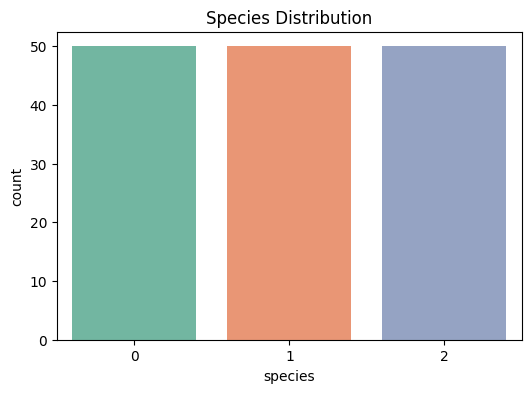

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='species',
    data=df,
    palette='Set2'
)

plt.title("Species Distribution")
plt.show()

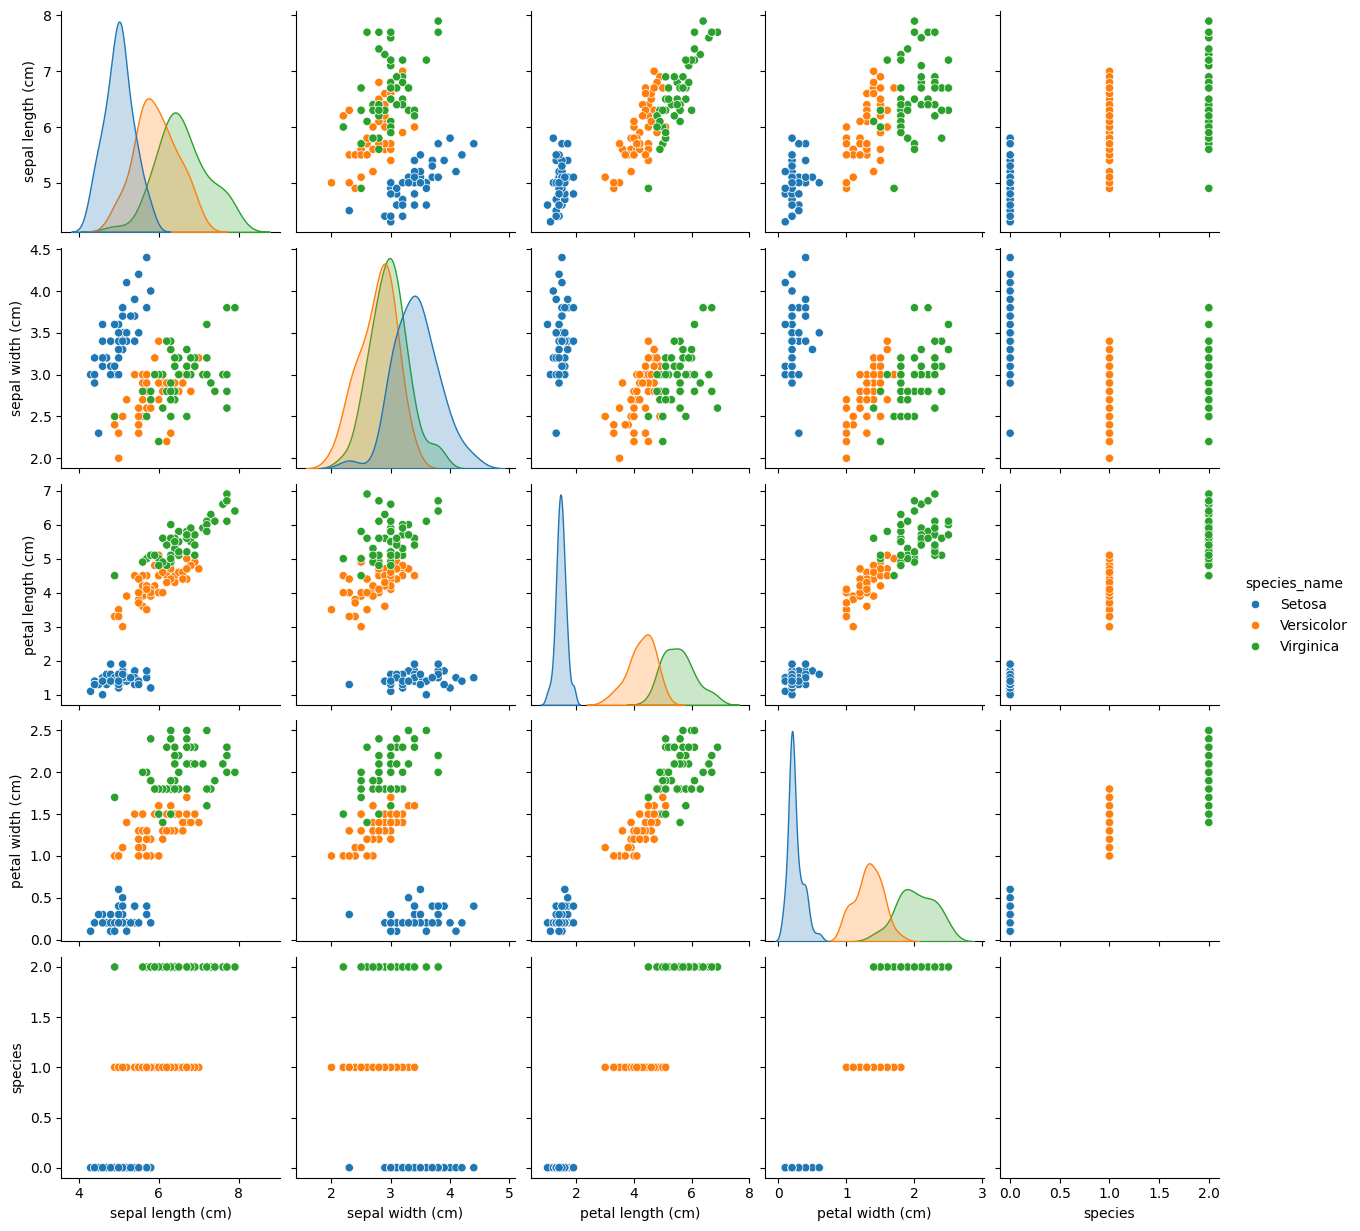

In [ ]:
df['species_name'] = df['species'].map({
    0:'Setosa',
    1:'Versicolor',
    2:'Virginica'
})

sns.pairplot(
    df,
    hue='species_name'
)

plt.show()

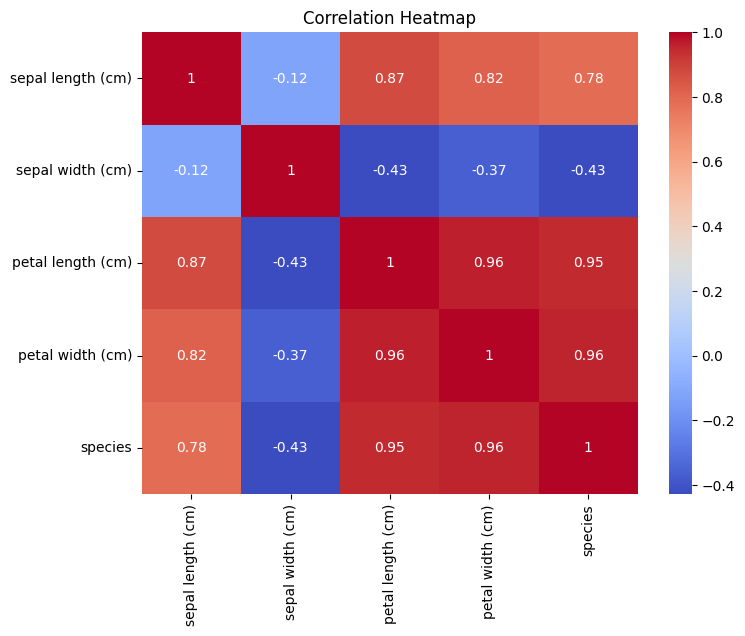

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=3
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9333333333333333


In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9333333333333333


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9


                 Model  Accuracy
0  Logistic Regression  0.933333
1                  KNN  0.933333
2        Decision Tree  0.933333
3        Random Forest  0.900000


/tmp/ipykernel_11329/2122894818.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


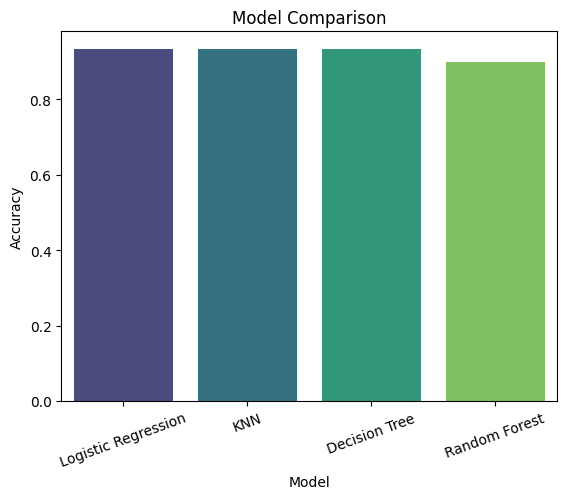

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print(results)

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette='viridis'
)

plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

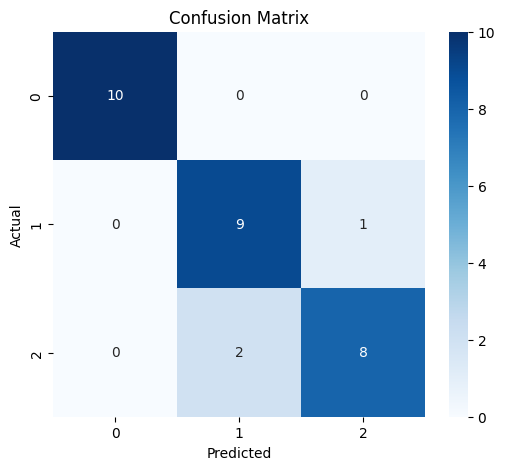

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [ ]:
joblib.dump(
    rf_model,
    "iris_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
model = joblib.load(
    "iris_model.pkl"
)

scaler = joblib.load(
    "scaler.pkl"
)

print("Model Loaded")

Model Loaded


In [ ]:
# Example flower

sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 0.2

input_data = np.array([
    [
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]
])

input_data = scaler.transform(
    input_data
)

prediction = model.predict(
    input_data
)

species_names = [
    'Setosa',
    'Versicolor',
    'Virginica'
]

print(
    "Predicted Species:",
    species_names[prediction[0]]
)

Predicted Species: Setosa


In [ ]:
model = joblib.load(
    "iris_model.pkl"
)

scaler = joblib.load(
    "scaler.pkl"
)

sl = float(input("Enter Sepal Length: "))
sw = float(input("Enter Sepal Width: "))
pl = float(input("Enter Petal Length: "))
pw = float(input("Enter Petal Width: "))

data = np.array([
    [sl, sw, pl, pw]
])

data = scaler.transform(data)

prediction = model.predict(data)

species = [
    "Setosa",
    "Versicolor",
    "Virginica"
]

print(
    "\nPredicted Flower Species:",
    species[prediction[0]]
)

Enter Sepal Length: 4
Enter Sepal Width: 5
Enter Petal Length: 9
Enter Petal Width: 1

Predicted Flower Species: Virginica
